# 28. Polynomial Regression — Hands-On with scikit-learn

Every regression topic so far — [`26_Simple_Linear_Regression.ipynb`](26_Simple_Linear_Regression.ipynb), [`27_Multiple_Linear_Regression.ipynb`](27_Multiple_Linear_Regression.ipynb) — fit a **straight line** (or flat plane) through the data. Polynomial Regression is for when the real relationship **curves**: it models `y` as an *n*th-degree polynomial of `x`:

`y = b0 + b1·x + b2·x² + b3·x³ + ... + bn·xⁿ`

It's still called *linear* regression under the hood — "linear" refers to the coefficients (`b0, b1, b2, ...`) being combined in a straight-forward sum, not to the shape of the curve itself. In practice, this means: build new columns (`x`, `x²`, `x³`, ...) out of the one original column, then hand those to the exact same `LinearRegression` used in the last two notebooks. No new algorithm — just new features.

`polynomial_dataset.csv` is the classic teaching example for this: 16 job levels (`Level`) and the salary that comes with each (`Salary`). Salary doesn't grow by a fixed amount per level — it accelerates, curving upward. A straight line can't hug that curve; a polynomial can.

This notebook: load and look at the data, fit an ordinary straight-line model first (and watch it fail to hug the curve — the same "Simple linear model vs Polynomial model" comparison from the course slide), then build polynomial features and train the real model with the same `train_test_split` habit used in [`26_`](26_Simple_Linear_Regression.ipynb) and [`27_`](27_Multiple_Linear_Regression.ipynb), compare degrees, and finish by predicting an in-between level to see how differently a line and a curve handle it.

In [1]:
import pandas as pd                                      # pandas: load the CSV and work with it as a table (DataFrame)
import numpy as np                                       # numpy: build the smooth grid of x-values used to draw curves
import matplotlib.pyplot as plt                          # matplotlib: plotting
from sklearn.linear_model import LinearRegression         # fits a straight line — used both alone and after polynomial transforms
from sklearn.preprocessing import PolynomialFeatures      # turns one column (Level) into Level, Level², Level³, ... columns
from sklearn.model_selection import train_test_split      # splits data into a training pool and a held-back testing pool

## Step 1 — Load the dataset

In [2]:
dataset = pd.read_csv("polynomial_dataset.csv")  # read the CSV file from disk into a pandas DataFrame called "dataset"

## Step 2 — Look at the data

Only 16 rows this time, so we can look at the whole thing at once instead of just a `head()`.

In [3]:
dataset  # small dataset — display every row

,Level,Salary
0,1,1798
1,2,3981
2,3,7874
3,4,12812
4,5,17433
5,6,23933
6,7,32340
7,8,40434
8,9,49315
9,10,60321


## Step 3 — Check the shape

In [4]:
dataset.shape  # (rows, columns) — 16 job levels, 2 columns

(16, 2)

## Step 4 — Check for missing values

Same habit as every earlier `ML/` topic: confirm there are no gaps before training anything.

In [5]:
dataset.isnull().sum()  # count missing values per column — should be 0

Level     0
Salary    0
dtype: int64

## Step 5 — Visualize the raw relationship

Before fitting anything, look at the shape of the data. `Level` climbs by a fixed step (1, 2, 3, ...), but `Salary` doesn't rise by a fixed amount each time — the gap between consecutive salaries keeps growing. That accelerating, curved shape is the whole reason this topic exists: a straight line is built to add a *constant* amount of `y` per unit of `x`, which is exactly the one thing this data isn't doing.

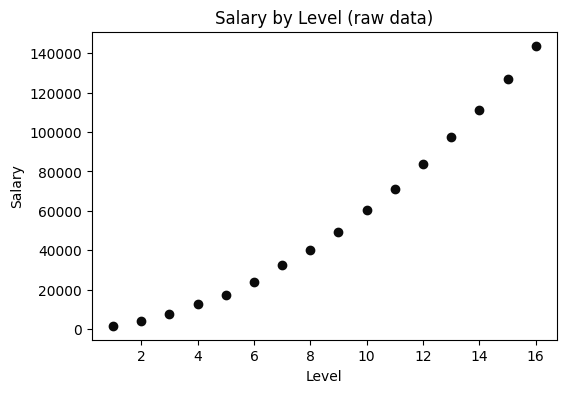

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(dataset["Level"], dataset["Salary"], color="#0b0b0b")   # actual data — dark dots, no fit line yet
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Salary by Level (raw data)")
plt.show()

## Step 6 — Split into `x` (input) and `y` (target)

`x` is built with double square brackets (`dataset[["Level"]]`) so it comes out as a 2-D DataFrame — the shape `scikit-learn` expects — rather than a 1-D Series, avoiding the manual reshape that a single-bracket `x` needed back in [`26_`](26_Simple_Linear_Regression.ipynb).

In [7]:
x = dataset[["Level"]]   # double brackets -> 2-D DataFrame (1 column), the shape scikit-learn expects
y = dataset["Salary"]    # single bracket -> 1-D Series, the target
x.ndim, y.ndim           # confirm: 2 for x, 1 for y

(2, 1)

## Step 7 — A quick straight-line baseline

Before reaching for anything fancier, fit the simplest possible model straight onto the raw `x` and `y` — an ordinary `LinearRegression`, no transformation. This one is deliberately quick and rough: it's fit on the *whole* dataset with no train/test split, purely to see *how* a straight line fails before building the real, properly-evaluated polynomial model in the next steps.

In [8]:
lin_reg = LinearRegression()   # a plain straight-line model, same class used in every regression notebook so far
lin_reg.fit(x, y)              # fit it directly on Level -> Salary, no transformation, no split — just a quick visual baseline

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9438.72]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Level']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.494e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## Step 8 — Turn one column into many (`PolynomialFeatures`)

`PolynomialFeatures(degree=2)` takes the single `Level` column and builds a new table with `Level` and `Level²` as extra columns (plus a constant `1` column by default — `include_bias=True`). That's the entire trick behind polynomial regression: it's a feature-engineering step, not a different algorithm — the same `LinearRegression` fits a straight-line-style equation on top of these curved features, which is what lets the *combined* result curve.

The result is kept as a separate `x_poly`, rather than overwriting `x`, so the original single `Level` column stays available below for the baseline comparison chart. Because `PolynomialFeatures` only ever looks at *one row at a time* — `Level²` for a row never depends on any other row's `Level` — there's no "peeking at the test set" risk in transforming before splitting, unlike a transformer such as `StandardScaler` (see [`15_Feature_Scaling.ipynb`](15_Feature_Scaling.ipynb)) that computes a mean/std *across* rows and genuinely would leak test-set information if fit before the split.

In [9]:
pf = PolynomialFeatures(degree=2)   # will build: [1, Level, Level^2] — 3 columns (bias column included by default)
pf.fit(x)                            # learn how many/which power columns to build, from x's shape
x_poly = pf.transform(x)             # apply that transform — x_poly now has 3 columns instead of x's 1
x_poly.shape                         # confirm shape: (16, 3)

(16, 3)

## Step 9 — Split into train and test sets

Same habit as [`26_`](26_Simple_Linear_Regression.ipynb) and [`27_`](27_Multiple_Linear_Regression.ipynb): hold back 20% as a test set the model never trains on, so its score means something. `random_state=42` keeps the split reproducible. Worth being honest about the one real tradeoff here: 20% of only 16 rows is **4 test rows** — far too few to be a statistically solid estimate on its own. The split is still applied, both because it's the same evaluation habit used everywhere else in this series and because it's what the underlying course teaches — just don't over-trust a single R² computed from 4 points the way you might trust one computed from hundreds.

In [10]:
x_train, x_test, y_train, y_test, idx_train, idx_test = train_test_split(
    x_poly, y, dataset.index, test_size=0.2, random_state=42
)   # split the polynomial-expanded columns; idx_train/idx_test carry along which original rows landed in each split
len(x_train), len(x_test)   # 12 rows to train on, 4 held back to test on

(12, 4)

## Step 10 — Train the polynomial model

Same model class, same `.fit()` call as Step 7 — the only differences are that it's looking at the 3 polynomial columns instead of 1, and only at the *training* rows.

In [11]:
poly_reg = LinearRegression()      # another plain LinearRegression — the curve comes entirely from the input columns, not the model
poly_reg.fit(x_train, y_train)     # train only on the 12 training rows

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,977.54,496.94]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,623.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[256.93, 2.72, 0. ]"


## Step 11 — Score the model on unseen data

`.score()` returns R² on the 4 held-out test rows — the model never saw these during training. This is the number that should actually be trusted as "how good is this model," as opposed to the Step 7 baseline, which was never evaluated this rigorously.

In [12]:
print(f"Test R²  (degree 2, held-out 4 rows): {poly_reg.score(x_test, y_test):.4f}")
print(f"Train R² (degree 2, seen 12 rows):        {poly_reg.score(x_train, y_train):.4f}")

Test R²  (degree 2, held-out 4 rows): 0.9999
Train R² (degree 2, seen 12 rows):        0.9999


## Step 12 — Simple Linear Model vs Polynomial Model, side by side

This is the exact comparison from the course slide: a straight line forced through curved data on the left, the polynomial model on the right. Training rows are plotted as filled dark dots, the 4 held-out test rows are outlined in the same accent color as their fit line, so it's visible which points the polynomial model never saw during training. Since `Level` only takes whole-number steps (1–16), a smooth-looking curve needs a *finer* grid of x-values than the data itself provides — `np.linspace` builds 200 evenly spaced points between 1 and 16, each pushed through the same `pf.transform()` used in training, so the model predicts a salary for each; plotting straight lines between those close-together points reads as one smooth curve.

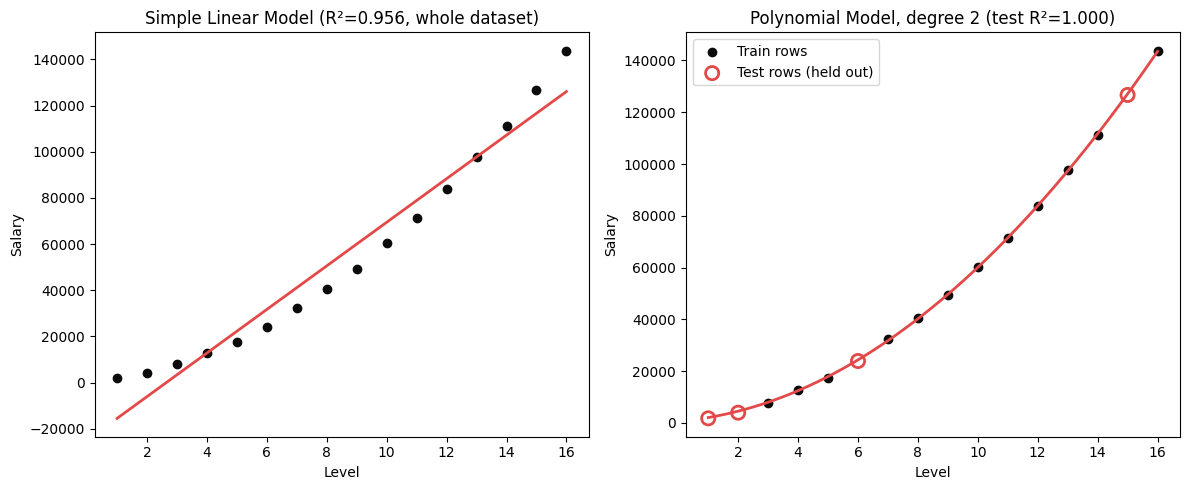

In [13]:
level_grid = pd.DataFrame({"Level": np.linspace(x["Level"].min(), x["Level"].max(), 200)})   # 200 evenly spaced Level values, as a 1-column DataFrame
salary_curve = poly_reg.predict(pf.transform(level_grid))                                          # predicted salary at every one of those 200 points

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(x, y, color="#0b0b0b")
axes[0].plot(x, lin_reg.predict(x), color="#e34948", linewidth=2)
axes[0].set_title(f"Simple Linear Model (R²={lin_reg.score(x, y):.3f}, whole dataset)")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Salary")

axes[1].scatter(dataset.loc[idx_train, "Level"], dataset.loc[idx_train, "Salary"], color="#0b0b0b", label="Train rows")
axes[1].scatter(dataset.loc[idx_test, "Level"], dataset.loc[idx_test, "Salary"], facecolors="none", edgecolors="#e34948", s=90, linewidth=2, label="Test rows (held out)")
axes[1].plot(level_grid, salary_curve, color="#e34948", linewidth=2)
axes[1].set_title(f"Polynomial Model, degree 2 (test R²={poly_reg.score(x_test, y_test):.3f})")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Salary")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 13 — Compare multiple degrees at once

Why degree 2, and not 3 or 4? This chart repeats the same fit-on-train, score-on-test workflow for degrees 1, 2, 3, and 4, and draws every resulting curve on the same axes. Degree 1 (the plain line) tests clearly worse than everything else — but degrees 2, 3, and 4 all land in the same tight neighborhood on test R², since this dataset's true shape is close to a simple curve (a parabola) that degree 2 already captures. Degrees 3 and 4 aren't "more correct" here, they're just not needed — the honest lesson is that more degrees isn't automatically a better fit, only useful up to however many bends the real relationship actually has. Past that point, extra degrees mostly add flexibility to fit noise instead of signal (overfitting), which is easiest to catch precisely by scoring on held-out rows like this rather than on the same rows the model trained on.

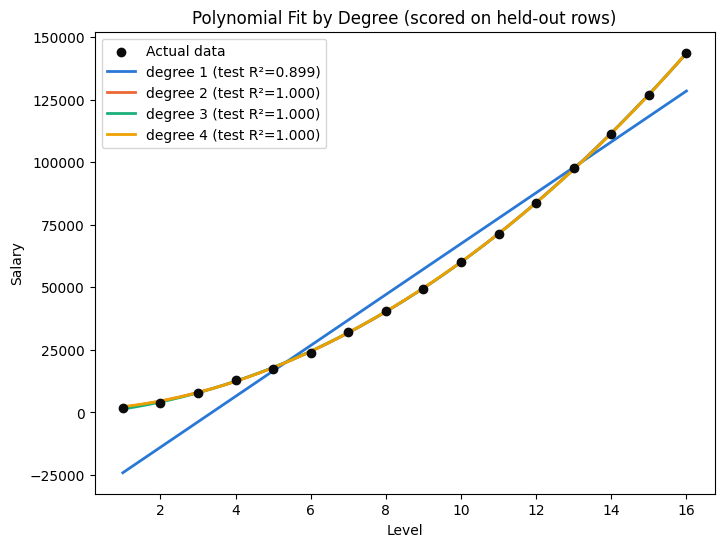

In [14]:
degrees = [1, 2, 3, 4]
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # one fixed color per degree, in order

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color="#0b0b0b", label="Actual data", zorder=5)

for degree, color in zip(degrees, colors):
    pf_d = PolynomialFeatures(degree=degree)                                        # this degree's own transformer
    x_deg = pf_d.fit_transform(x)
    x_deg_train, x_deg_test, y_deg_train, y_deg_test = train_test_split(x_deg, y, test_size=0.2, random_state=42)   # same split every time (same random_state)
    model = LinearRegression()
    model.fit(x_deg_train, y_deg_train)                                             # fit on this degree's training rows
    grid_pred = model.predict(pf_d.transform(level_grid))                           # predict across the same smooth grid from Step 12
    test_r2 = model.score(x_deg_test, y_deg_test)
    plt.plot(level_grid, grid_pred, color=color, linewidth=2, label=f"degree {degree} (test R²={test_r2:.3f})")

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Polynomial Fit by Degree (scored on held-out rows)")
plt.legend()
plt.show()

## Step 14 — Predict an in-between level, both ways

Imagine a candidate describes their previous role as "a bit above level 6" — there's no exact row for that in the data. `Level = 6.5` doesn't exist in `dataset`, so this is a genuine prediction, not a lookup. Comparing what the quick straight-line baseline says against what the properly-trained degree-2 model says shows exactly why the choice of model matters in practice: they don't just differ slightly, they can disagree by a large margin, and only one of them is actually tracking the visible curve.

In [15]:
new_level = pd.DataFrame({"Level": [6.5]})                       # a level that isn't in the original data

linear_prediction = lin_reg.predict(new_level)[0]
poly_prediction = poly_reg.predict(pf.transform(new_level))[0]

print(f"Simple Linear Model predicts:      ₹{linear_prediction:,.0f}")
print(f"Polynomial Model (deg 2) predicts: ₹{poly_prediction:,.0f}")

Simple Linear Model predicts:      ₹36,410
Polynomial Model (deg 2) predicts: ₹27,973


## Step 15 — See that prediction on the chart

Marking both predicted points for `Level = 6.5` on top of the degree-2 curve and the actual neighboring data (`Level 6` = ₹23,933, `Level 7` = ₹32,340) makes the gap concrete: one prediction sits right on the curve between its neighbors, the other doesn't.

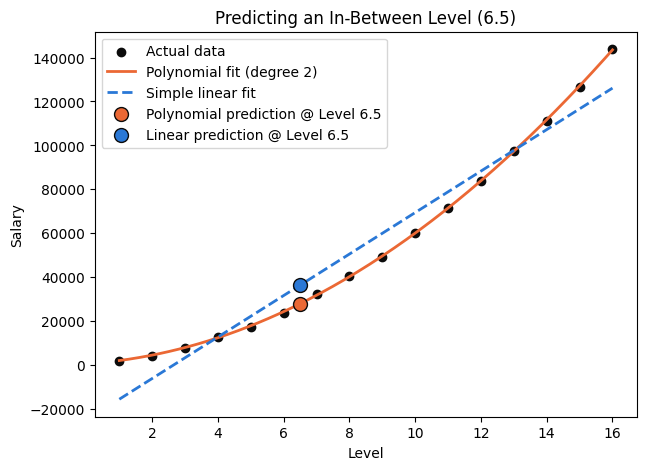

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color="#0b0b0b", label="Actual data")
plt.plot(level_grid, salary_curve, color="#eb6834", linewidth=2, label="Polynomial fit (degree 2)")
plt.plot(x, lin_reg.predict(x), color="#2a78d6", linewidth=2, linestyle="--", label="Simple linear fit")
plt.scatter([6.5], [poly_prediction], color="#eb6834", edgecolor="#0b0b0b", s=100, zorder=5, label="Polynomial prediction @ Level 6.5")
plt.scatter([6.5], [linear_prediction], color="#2a78d6", edgecolor="#0b0b0b", s=100, zorder=5, label="Linear prediction @ Level 6.5")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Predicting an In-Between Level (6.5)")
plt.legend()
plt.show()

## Key Takeaways

- Polynomial Regression isn't a new algorithm — it's `PolynomialFeatures` turning one column into several curved ones (`x, x², ...`), then the same `LinearRegression` from every earlier topic fits a straight-line-style equation on top of them.
- It's still called *linear* regression because it's linear in the coefficients (`b0, b1, b2, ...`), not because the resulting curve is straight.
- `PolynomialFeatures` is safe to `fit_transform` on the whole `x` before splitting, since each row's new columns only depend on that row's own value — no cross-row statistic gets learned, unlike a transformer such as `StandardScaler` that would leak test-set information if fit before the split.
- The same `train_test_split` habit from [`26_`](26_Simple_Linear_Regression.ipynb)/[`27_`](27_Multiple_Linear_Regression.ipynb) still applies here, even on a 16-row dataset — just be honest that scoring on 4 held-out rows is a small, noisier sample than scoring on hundreds.
- Raising the polynomial degree lets the curve bend more, but past however many bends the real relationship actually has, extra degrees mostly add flexibility to fit noise instead of signal (overfitting) — visible more reliably in *test* R² than in R² measured on the same rows the model trained on.
- Predicting at a point that isn't in the training data (`Level = 6.5`) is where a straight line and a well-fit curve can disagree the most — and it's exactly the kind of real prediction a model gets used for.